# *1.1/ IMPORTATION DES BIBLIOTHEQUES*

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
  
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)

import warnings
warnings.filterwarnings("ignore")

# *1.2/ CHARGEMENT DES DONNEES* 

In [2]:
df = pd.read_csv("heart_disease_uci.csv")

print(df.shape)
df.head()

(920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# *2/ EDA*

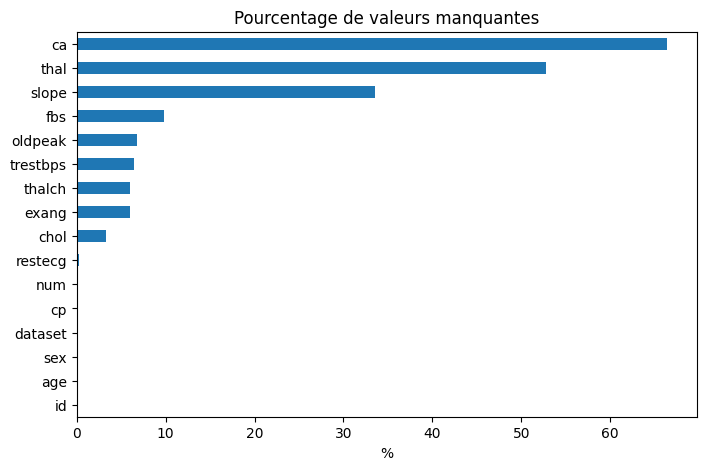

In [3]:
#Statistiques descriptives

df.describe()
df.describe(include='object')


#Analyse de valeurs manquantes

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
}).sort_values(by='Percentage', ascending=False)

missing_df
plt.figure(figsize=(8,5))
missing_percent.sort_values().plot(kind='barh')
plt.title("Pourcentage de valeurs manquantes")
plt.xlabel("%")
plt.show()

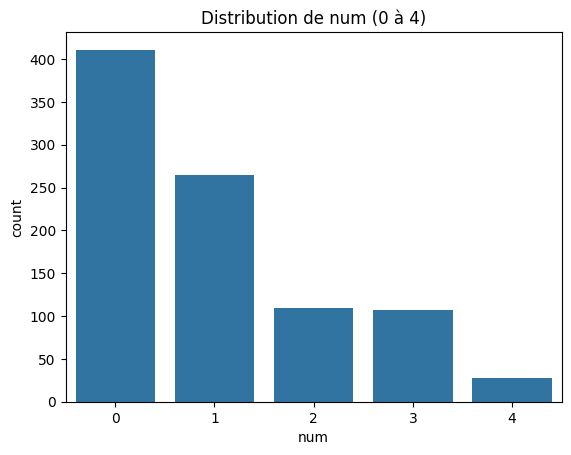

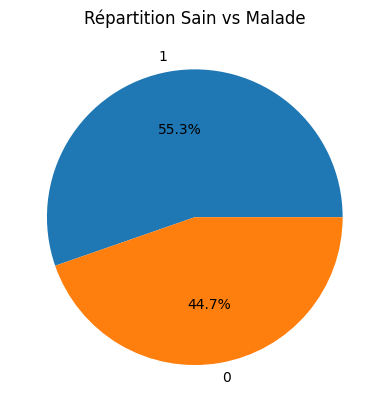

In [4]:
#distribution de la variable cible 

sns.countplot(x='num', data=df)
plt.title("Distribution de num (0 à 4)")
plt.show()
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

df['target'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Répartition Sain vs Malade")
plt.ylabel("")
plt.show()

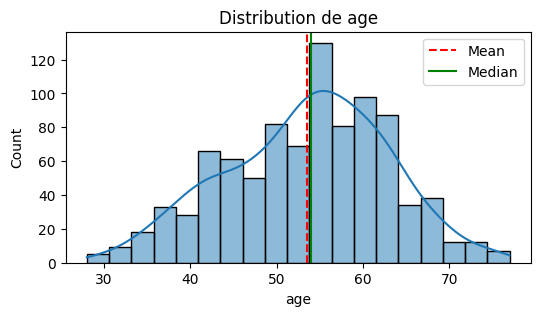

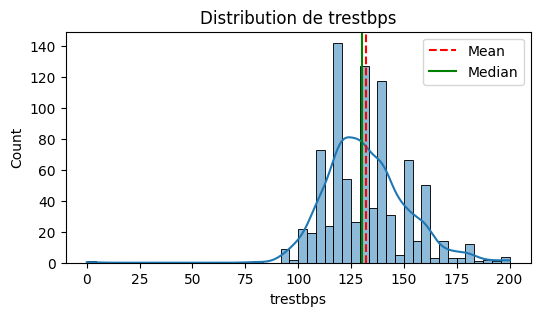

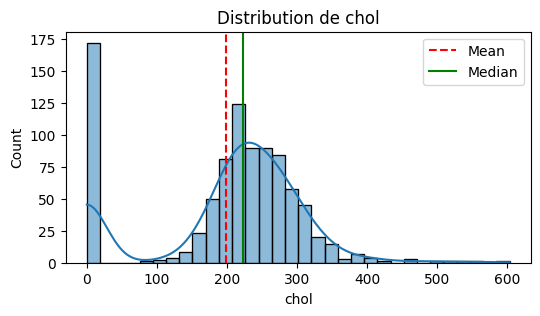

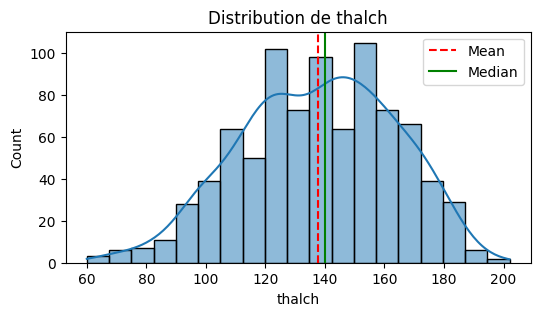

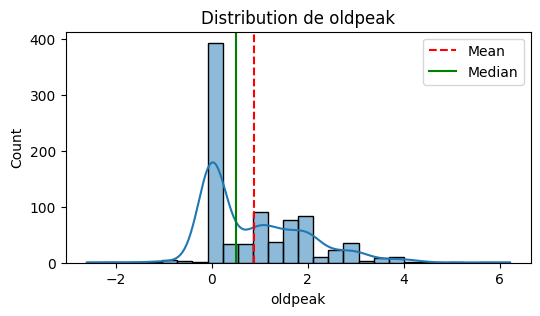

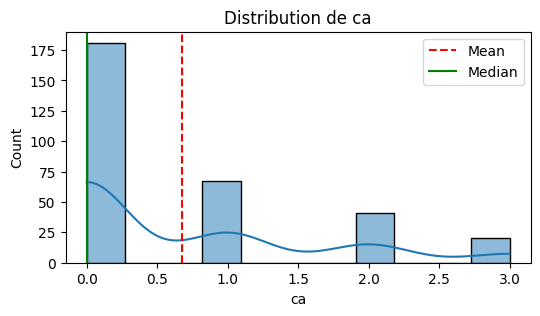

In [5]:
#distribution des variables numeriques

num_cols = ['age','trestbps','chol','thalch','oldpeak','ca']
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    
    plt.axvline(df[col].mean(), color='r', linestyle='--', label='Mean')
    plt.axvline(df[col].median(), color='g', linestyle='-', label='Median')
    
    plt.title(f"Distribution de {col}")
    plt.legend()
    plt.show()

**👉 distribution de chol, ca et oldpeak sont asymetriques**

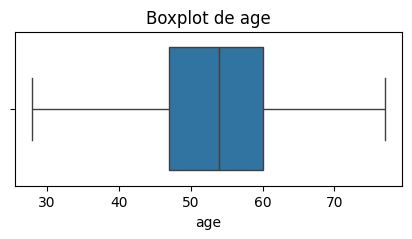

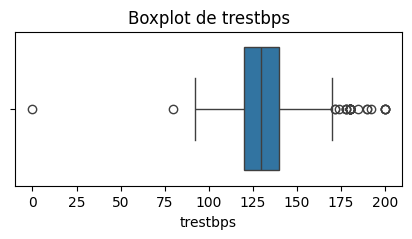

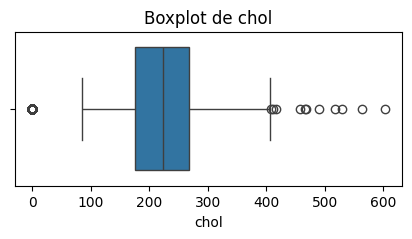

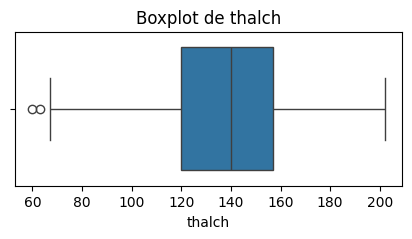

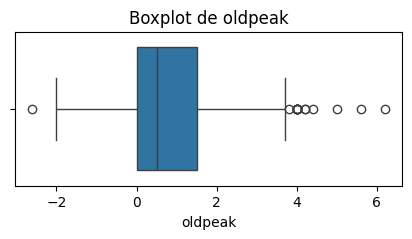

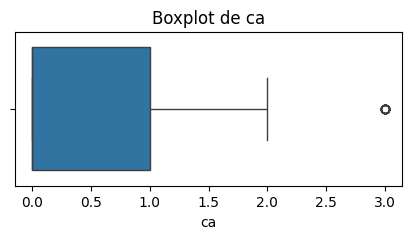

In [6]:
#outliers

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()


##  iqr pour chaque boxplot
* age:          Q1=46   |  Q3=60*
* trestbps:     Q1=119  |  Q3=141*
* chol:         Q1=175  |  Q3=267*
* thalch        Q1=120  |  Q3=158*
* oldpeak       Q1=0    |  Q3=1.5*
* ca            Q1=0    |  Q3=1*

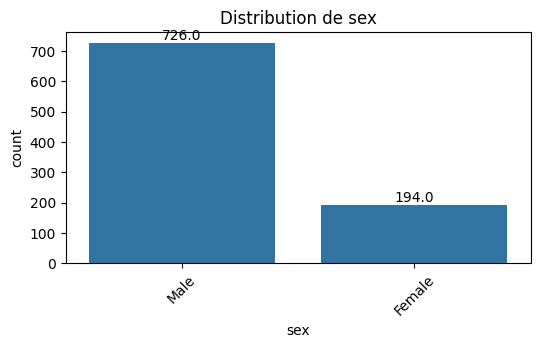

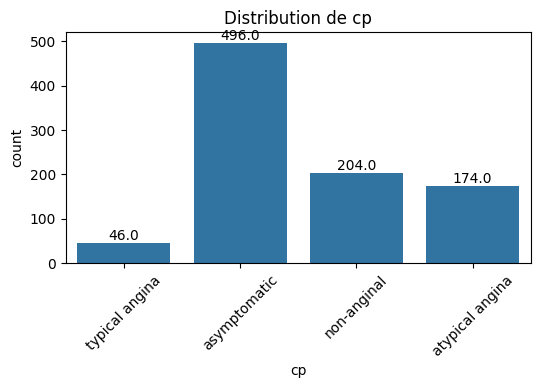

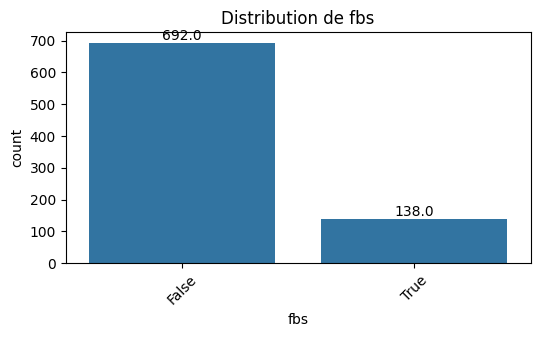

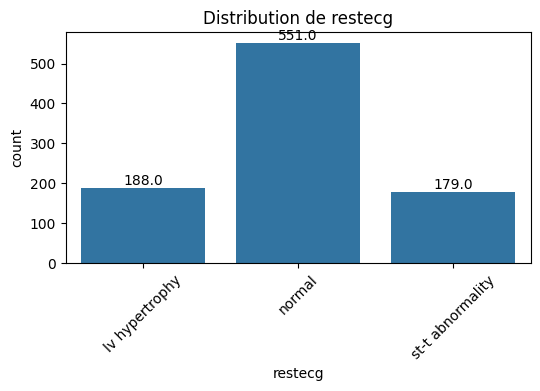

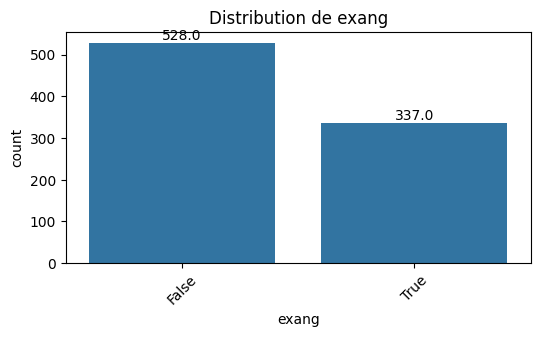

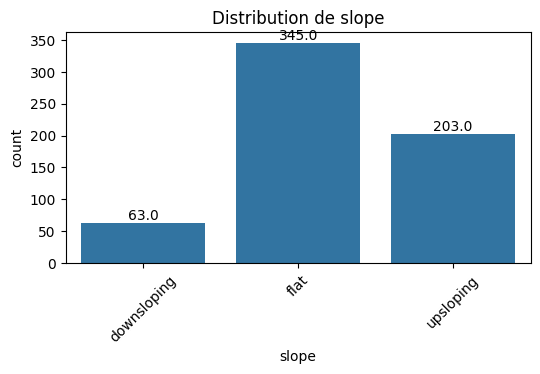

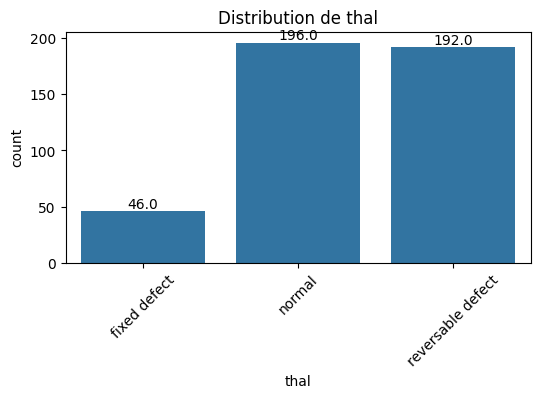

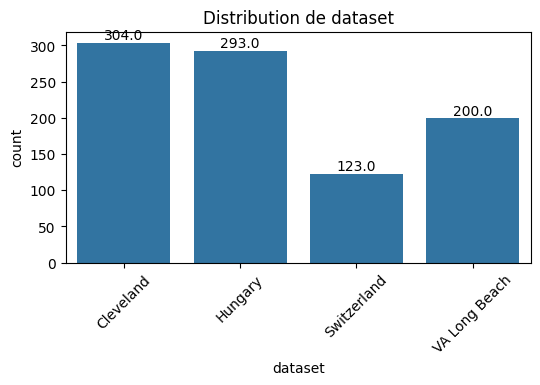

In [7]:
#distribution des variables categorielles
cat_cols = ['sex','cp','fbs','restecg','exang','slope','thal','dataset']
for col in cat_cols:
    plt.figure(figsize=(6,3))
    ax = sns.countplot(x=col, data=df)
    
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom')
    
    plt.title(f"Distribution de {col}")
    plt.xticks(rotation=45)
    plt.show()

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

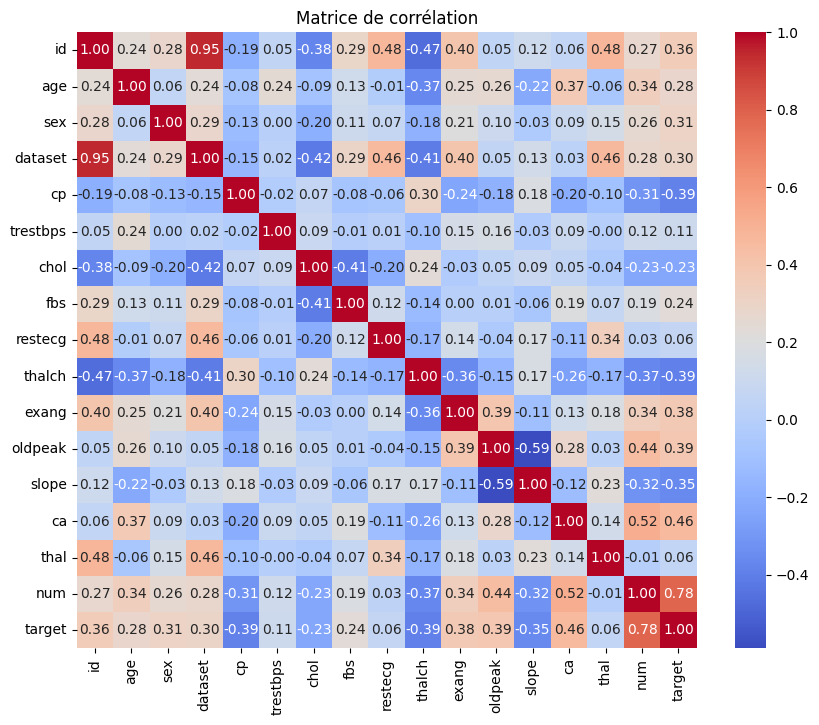

In [8]:
#matrice de correlation
df_encoded = df.copy()

le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    plt.figure(figsize=(10,8))
corr = df_encoded.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

## variables fortement corrélées:
* dataset et id r=0.95 *
* num et target r=0.78 *

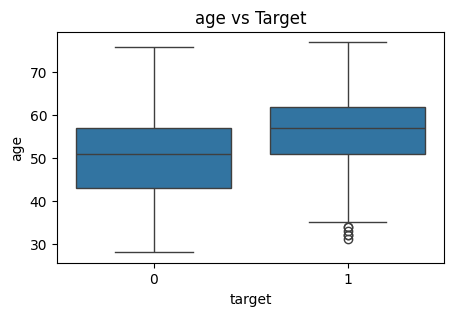

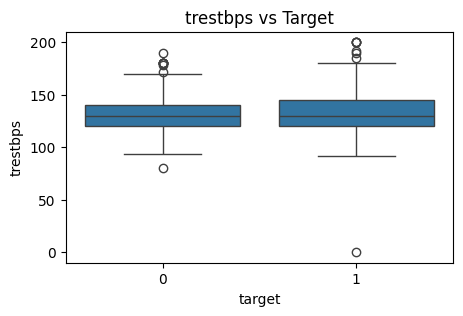

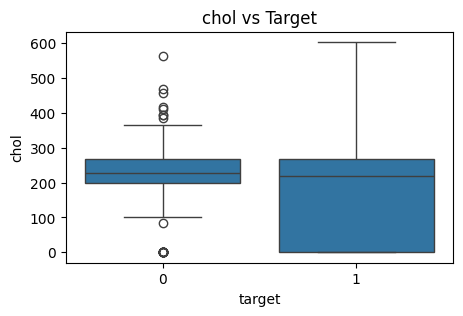

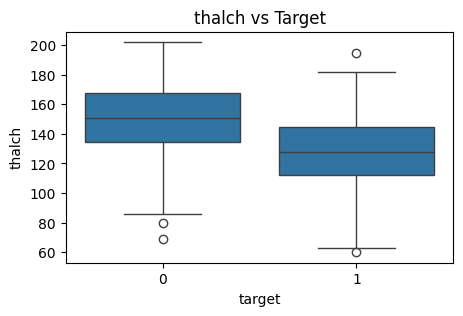

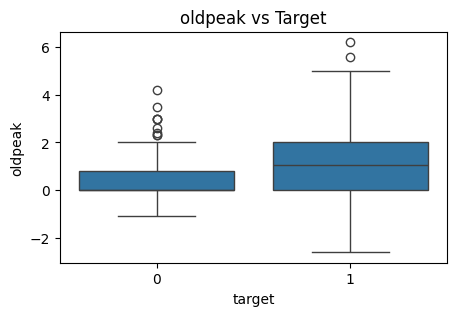

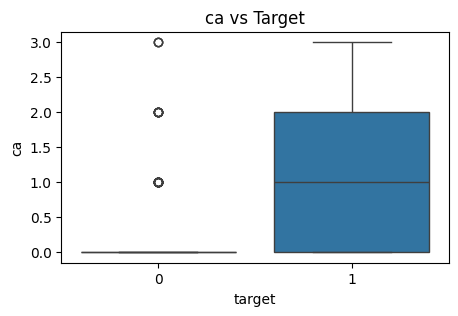

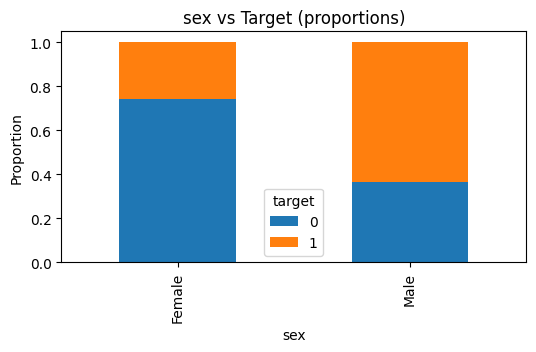

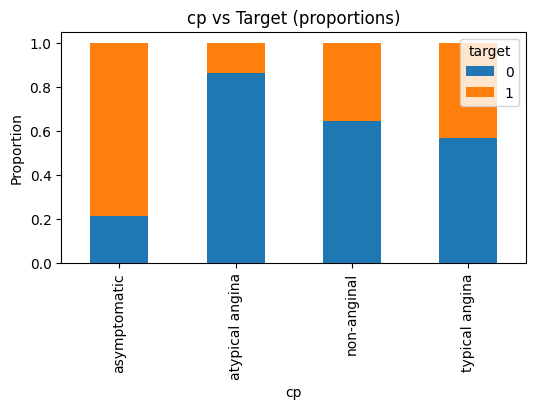

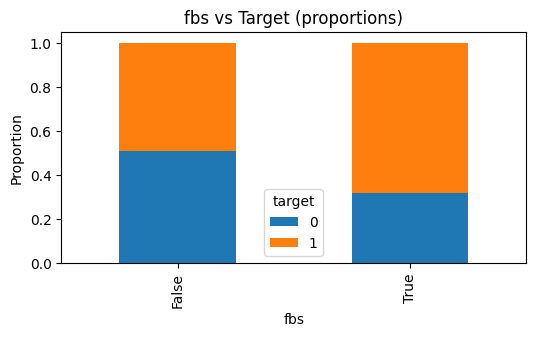

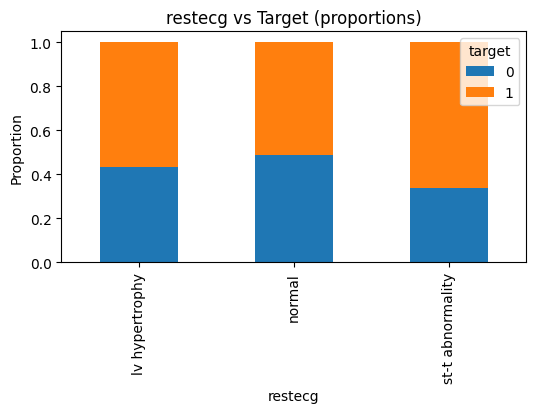

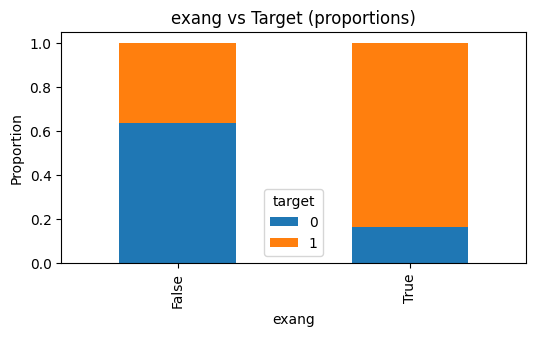

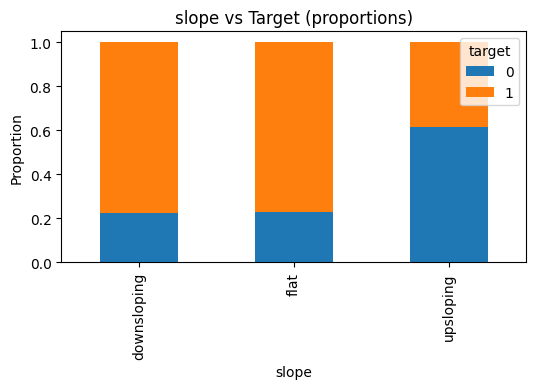

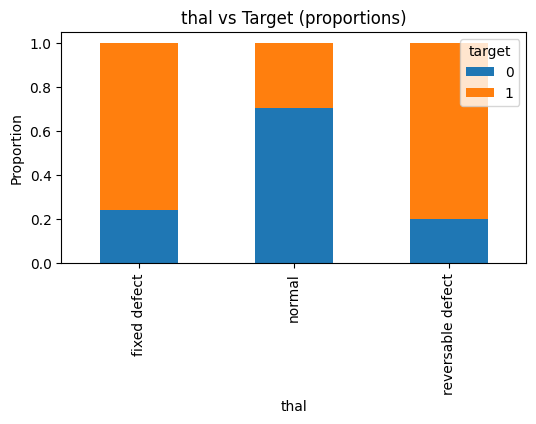

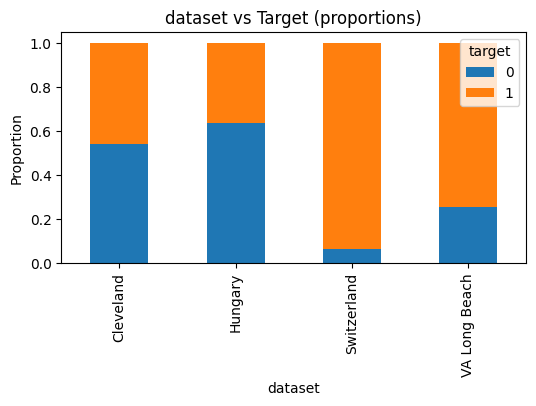

In [9]:
#boxplot: relation variables numerique vs target 
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

#stacked barplots: relation variables catego vs target 
for col in cat_cols:
    cross_tab = pd.crosstab(df[col], df['target'], normalize='index')
    
    cross_tab.plot(kind='bar', stacked=True, figsize=(6,3))
    plt.title(f"{col} vs Target (proportions)")
    plt.ylabel("Proportion")
    plt.show()

# *3/ NETTOYAGE ET PRETRAITEMENT*

In [10]:
#remplacement de num par target
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)
#supression de id , dataset et num
df.drop(columns=['id', 'dataset', 'num'], inplace=True) 

#trt de val manquantes
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
cat_cols = ['slope', 'thal', 'fbs', 'restecg', 'exang']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


# trt des val aberrantes
chol_median = df[df['chol'] > 0]['chol'].median()
trestbps_median = df[df['trestbps'] > 0]['trestbps'].median()
df.loc[df['chol'] == 0, 'chol'] = chol_median
df.loc[df['trestbps'] == 0, 'trestbps'] = trestbps_median

#encodage
le = LabelEncoder()
mapping_dict = {}
for col in ['sex','cp','fbs','restecg','exang','slope','thal']:
    df[col] = le.fit_transform(df[col])
    mapping = dict(zip(le.classes_, [int(x) for x in le.transform(le.classes_)]))
    mapping_dict[col] = mapping
for col, mapping in mapping_dict.items():
    print(f"\n{col} mapping:")
    print(mapping)

#separer features / target
X = df.drop(columns=['target'])
y = df['target']

#split train test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#standarisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)


sex mapping:
{'Female': 0, 'Male': 1}

cp mapping:
{'asymptomatic': 0, 'atypical angina': 1, 'non-anginal': 2, 'typical angina': 3}

fbs mapping:
{False: 0, True: 1}

restecg mapping:
{'lv hypertrophy': 0, 'normal': 1, 'st-t abnormality': 2}

exang mapping:
{False: 0, True: 1}

slope mapping:
{'downsloping': 0, 'flat': 1, 'upsloping': 2}

thal mapping:
{'fixed defect': 0, 'normal': 1, 'reversable defect': 2}


# *4/ MODELISATION - MODELES BASELINE*

In [11]:
models = {
    "LogReg_L2": LogisticRegression(),
    "LogReg_L1": LogisticRegression(penalty='l1', solver='liblinear'),
    "ElasticNet": LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5),
    "SVC": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:,1]
    results[name] = {
        "y_pred": y_pred,
        "y_proba": y_proba
    }
    print(f"{name} entraîné avec succès")

print(results['LogReg_L2'])

LogReg_L2 entraîné avec succès
LogReg_L1 entraîné avec succès
ElasticNet entraîné avec succès
SVC entraîné avec succès
KNN entraîné avec succès
DecisionTree entraîné avec succès
RandomForest entraîné avec succès
XGBoost entraîné avec succès
{'y_pred': array([0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1]), 'y_proba': array([0.30770093, 0.97892631, 0.90764113, 0.98028668, 0.42840613,
       0.81988158, 0.41584601, 0.93585096, 0.42088074

# *5/ EVALUATION DES MODELES*

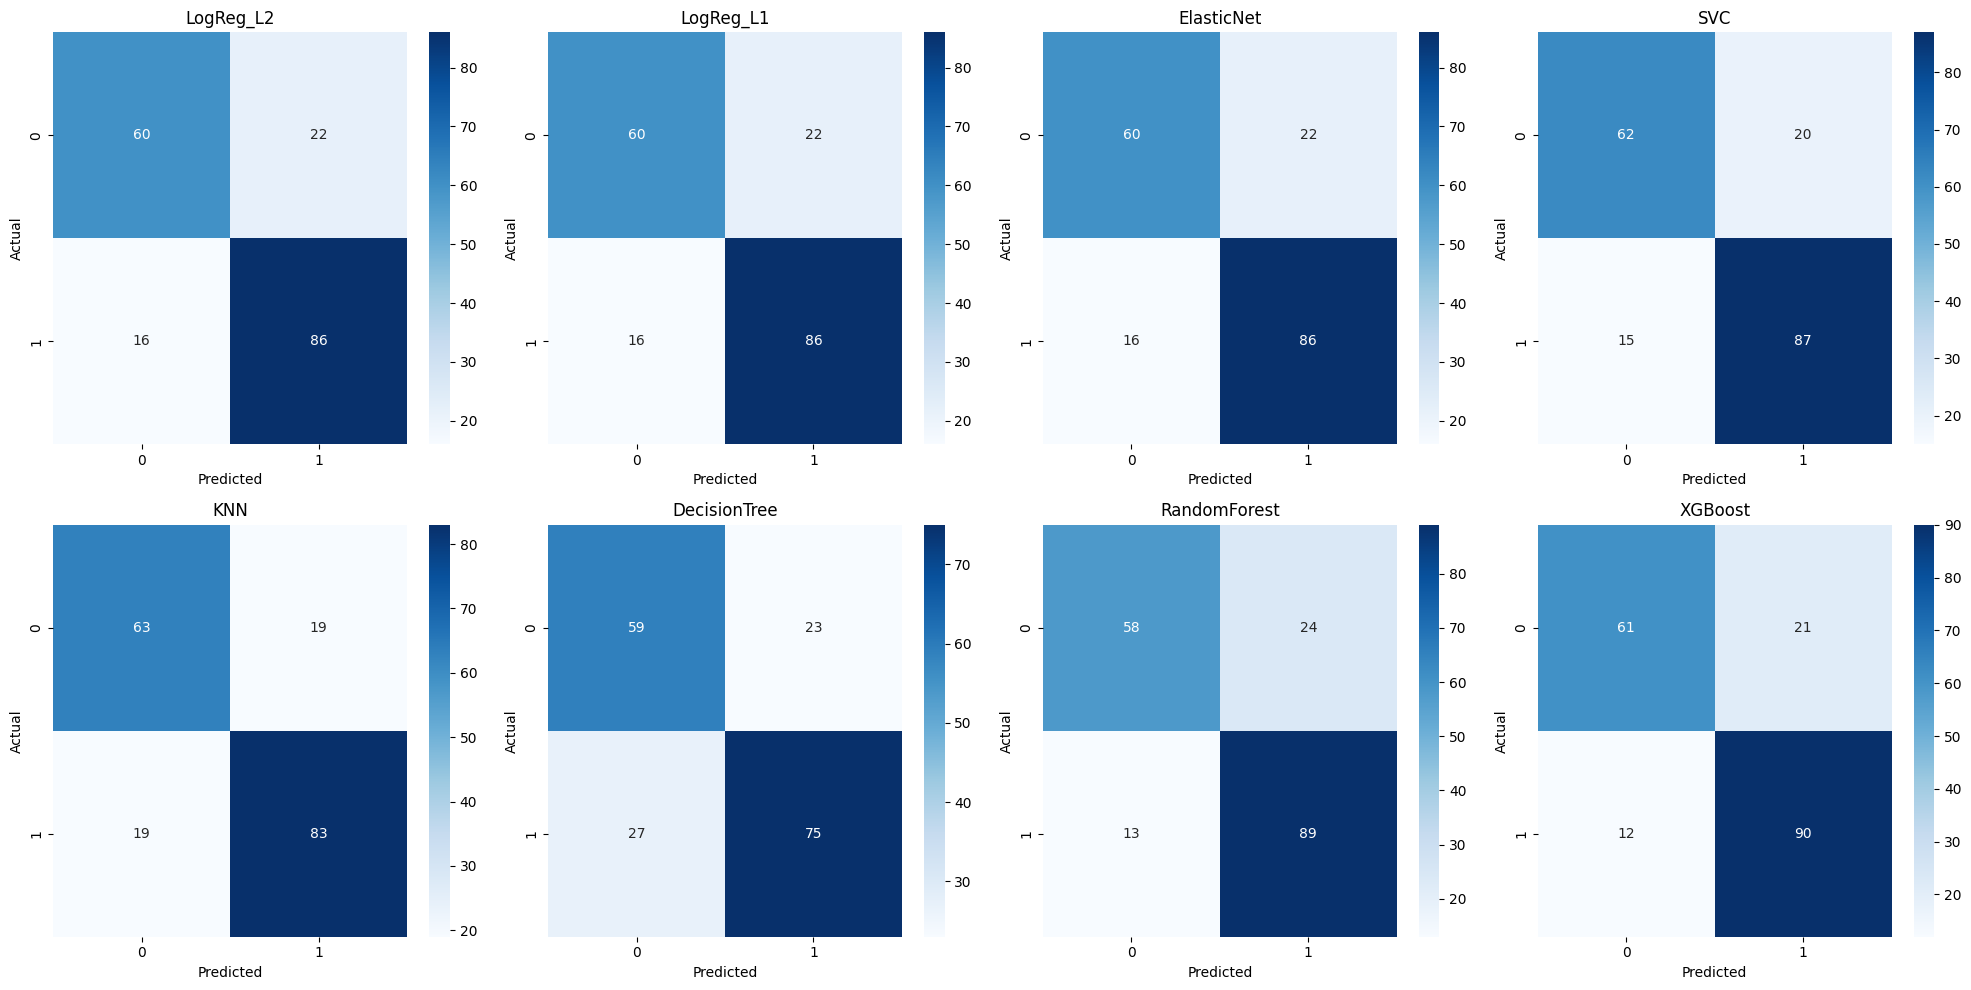

In [12]:
#matrice
fig, axes = plt.subplots(2, 4, figsize=(20,10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    
    cm = confusion_matrix(y_test, res["y_pred"])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()




In [13]:
#metrique (precison, recall etc)
for name, res in results.items():
    print(f"\n{name}")
    print(classification_report(y_test, res["y_pred"]))




LogReg_L2
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        82
           1       0.80      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184


LogReg_L1
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        82
           1       0.80      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184


ElasticNet
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        82
           1       0.80      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0

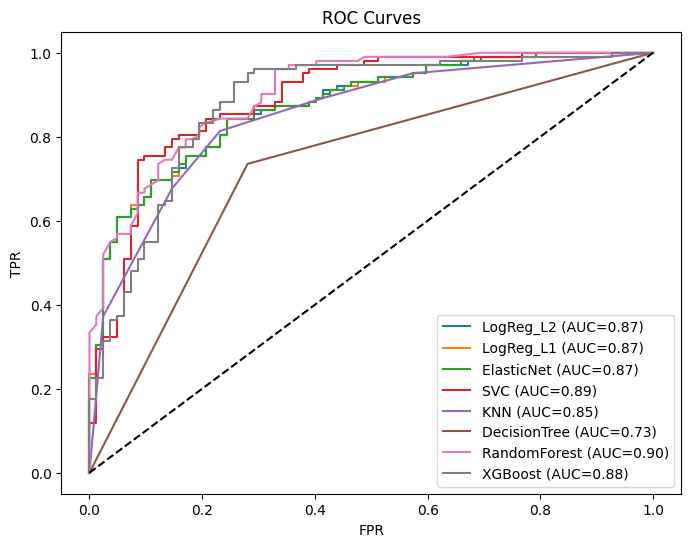

In [14]:
#roc / auc
plt.figure(figsize=(8,6))
for name, res in results.items():    
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    auc = roc_auc_score(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [15]:
#tableau final
results_list = []

for name, res in results.items():
    
    results_list.append([
        name,
        accuracy_score(y_test, res["y_pred"]),
        precision_score(y_test, res["y_pred"]),
        recall_score(y_test, res["y_pred"]),
        f1_score(y_test, res["y_pred"]),
        roc_auc_score(y_test, res["y_proba"])
    ])

results_df = pd.DataFrame(results_list, columns=[
    "Model","Accuracy","Precision","Recall","F1","ROC_AUC"
])

results_df = results_df.sort_values(by="ROC_AUC", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
6,RandomForest,0.798913,0.787611,0.872549,0.827907,0.904292
3,SVC,0.809783,0.813084,0.852941,0.832536,0.890363
7,XGBoost,0.820652,0.810811,0.882353,0.845070,0.880679
2,ElasticNet,0.793478,0.796296,0.843137,0.819048,0.874223
1,LogReg_L1,0.793478,0.796296,0.843137,0.819048,0.874103
0,LogReg_L2,0.793478,0.796296,0.843137,0.819048,0.873984
4,KNN,0.793478,0.813725,0.813725,0.813725,0.850610
5,DecisionTree,0.728261,0.765306,0.735294,0.750000,0.727403


# *6/ BACKWARD ELIMINATION*


###  Principe de la méthode Backward Elimination
La méthode de Backward Elimination est une technique de sélection de variables utilisée en régression, visant à conserver uniquement les variables les plus significatives.
Le principe est le suivant :
1. On commence avec toutes les variables explicatives dans le modèle.
2. On entraîne un modèle de régression .
3. On examine les p-values associées à chaque variable.
4. On identifie la variable ayant la plus grande p-value.
5. Si cette p-value est supérieure au seuil de significativité (α), on supprime cette variable.
6. On répète le processus jusqu’à ce que toutes les variables restantes soient significatives.
---

###  Définition de la p-value
La p-value mesure la probabilité d’obtenir un résultat au moins aussi extrême que celui observé, si l’hypothèse nulle (H₀) est vraie.
 Interprétation :
* Une p-value faible indique que la variable est probablement significative.
* Une p-value élevée suggère que la variable n’a pas d’impact significatif sur la variable cible.
---

###  Seuil de significativité (α = 0.05)
* Si p-value < 0.05 → variable significative 
* Si p-value ≥ 0.05 → variable non significative 
---

###  Hypothèses statistiques
Pour chaque variable, on teste :
* H₀ (hypothèse nulle) :
  La variable n’a aucun effet sur la variable cible.
* H₁ (hypothèse alternative) :
  La variable a un effet significatif sur la variable cible.

Décision :
* Si p-value < 0.05 → on rejette H₀
* Sinon → on ne rejette pas H₀
---

###  Objectif de la méthode
L’objectif de la Backward Elimination est de :
* Simplifier le modèle
* Éliminer les variables inutiles
* Améliorer l’interprétabilité
* Réduire le risque de surapprentissage (overfitting)




In [16]:
#implementation
X_be = sm.add_constant(X_train)
y_be = y_train

cols = list(X_be.columns)
selected_features = [col for col in cols if col != 'const']
history = []

step = 0

while True:
    
    model = sm.OLS(y_be, X_be[cols]).fit()
    
    pvalues = model.pvalues.drop('const')
    max_p = pvalues.max()
    
    # sauvegarder historique
    history.append({
        "step": step,
        "variables": cols.copy(),
        "max_p_value": max_p
    })
    
    print(f"\nStep {step}")
    print(pvalues)
    
    if max_p > 0.05:
        feature_to_remove = pvalues.idxmax()
        print(f"➡ Suppression de : {feature_to_remove} (p={max_p})")
        cols.remove(feature_to_remove)
        step += 1
    else:
        break

print("\nVariables finales :", cols)
X_selected = X_be[cols].drop(columns=['const'])
history_df = pd.DataFrame(history)
history_df

#retest
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]
scaler = StandardScaler()

X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel = scaler.transform(X_test_sel)
results_sel = {}

for name, model in models.items():
    
    model.fit(X_train_sel, y_train)
    
    y_pred = model.predict(X_test_sel)
    y_proba = model.predict_proba(X_test_sel)[:,1]
    
    results_sel[name] = {
        "y_pred": y_pred,
        "y_proba": y_proba
    }


Step 0
age         5.654004e-04
sex         1.545797e-11
cp          1.064350e-06
trestbps    9.950571e-01
chol        3.057746e-02
fbs         2.786194e-01
restecg     4.643789e-02
thalch      1.073767e-04
exang       9.554347e-08
oldpeak     6.336554e-05
slope       9.757076e-02
ca          8.710423e-05
thal        4.581546e-02
dtype: float64
➡ Suppression de : trestbps (p=0.9950571012125252)

Step 1
age        4.580873e-04
sex        1.369542e-11
cp         1.008819e-06
chol       3.019925e-02
fbs        2.752467e-01
restecg    4.626013e-02
thalch     1.059508e-04
exang      8.699512e-08
oldpeak    5.500190e-05
slope      9.725673e-02
ca         8.283359e-05
thal       4.515630e-02
dtype: float64
➡ Suppression de : fbs (p=0.27524674257202064)

Step 2
age        1.349856e-04
sex        6.971232e-12
cp         1.164984e-06
chol       2.593823e-02
restecg    4.081475e-02
thalch     1.479145e-04
exang      8.522079e-08
oldpeak    6.583944e-05
slope      7.689692e-02
ca         6.736001

In [17]:
#tab comparatif
comparison = []

for name in results.keys():
    
    # avant
    acc1 = accuracy_score(y_test, results[name]["y_pred"])
    auc1 = roc_auc_score(y_test, results[name]["y_proba"])
    
    # après
    acc2 = accuracy_score(y_test, results_sel[name]["y_pred"])
    auc2 = roc_auc_score(y_test, results_sel[name]["y_proba"])
    
    comparison.append([
        name,
        acc1, auc1,
        acc2, auc2
    ])

comparison_df = pd.DataFrame(comparison, columns=[
    "Model",
    "Accuracy_all", "AUC_all",
    "Accuracy_selected", "AUC_selected"
])

comparison_df

,Model,Accuracy_all,AUC_all,Accuracy_selected,AUC_selected
0,LogReg_L2,0.793478,0.873984,0.793478,0.873984
1,LogReg_L1,0.793478,0.874103,0.793478,0.874103
2,ElasticNet,0.793478,0.874223,0.793478,0.874223
3,SVC,0.809783,0.890363,0.809783,0.890363
4,KNN,0.793478,0.850610,0.793478,0.850610
5,DecisionTree,0.728261,0.727403,0.717391,0.716404
6,RandomForest,0.798913,0.904292,0.798913,0.892994
7,XGBoost,0.820652,0.880679,0.820652,0.880679


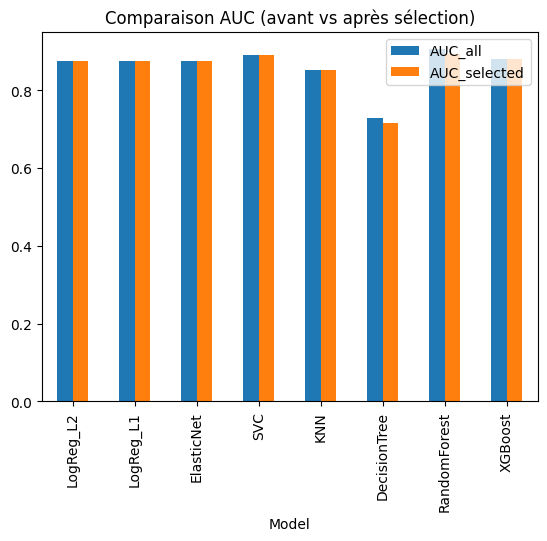

In [18]:
#grahphique de comparaison
comparison_df.set_index("Model")[["AUC_all","AUC_selected"]].plot(kind="bar")
plt.title("Comparaison AUC (avant vs après sélection)")
plt.show()

### Analyse 

La réduction dimensionnelle réalisée via la méthode de Backward Elimination a permis de supprimer les variables non significatives (p-value ≥ 0.05), afin de ne conserver que les variables ayant un impact statistiquement significatif sur la variable cible.

# *7/ FINE TUNING (GridSerachCV)*


🔍 Tuning LogReg_L2...
Best params: {'C': 0.1}

🔍 Tuning LogReg_L1...
Best params: {'C': 1}

🔍 Tuning ElasticNet...
Best params: {'C': 0.1, 'l1_ratio': 0.3}

🔍 Tuning SVC...
Best params: {'C': 0.1, 'kernel': 'rbf'}

🔍 Tuning KNN...
Best params: {'n_neighbors': 9}

🔍 Tuning DecisionTree...
Best params: {'max_depth': 5}

🔍 Tuning RandomForest...
Best params: {'max_depth': 5, 'n_estimators': 100}

🔍 Tuning XGBoost...
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

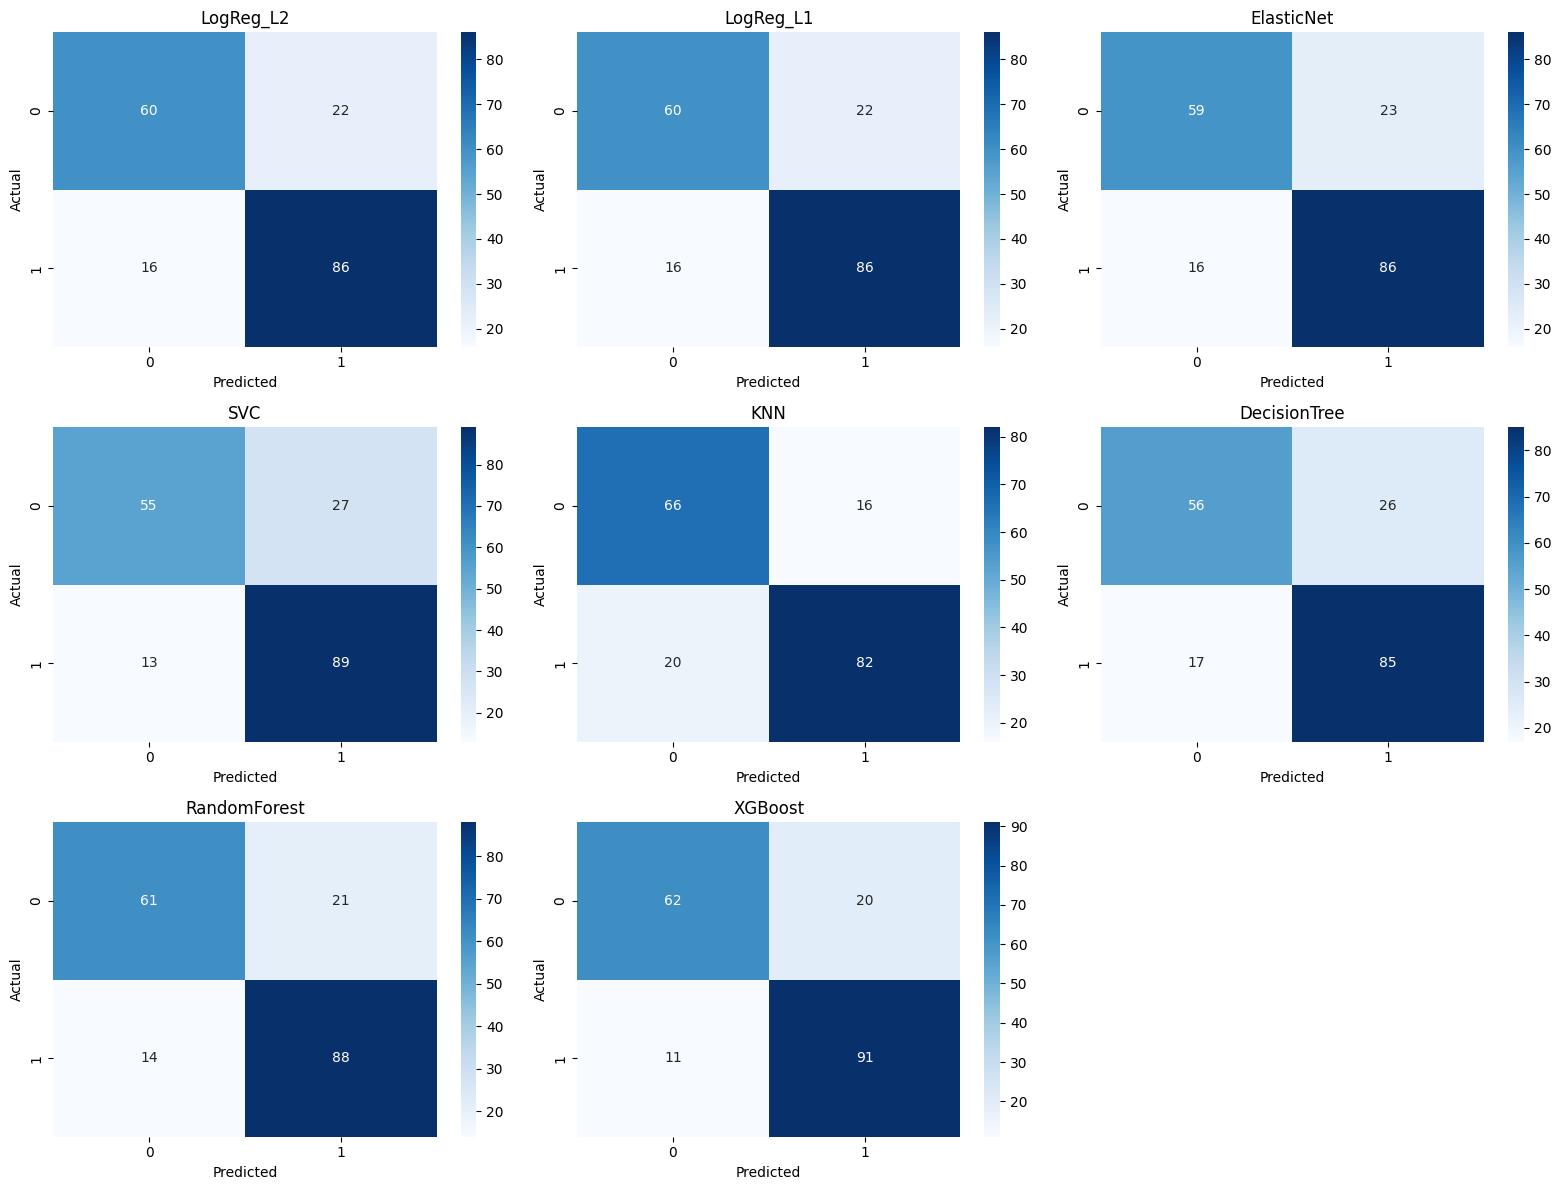


📌 LogReg_L2
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        82
           1       0.80      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184


📌 LogReg_L1
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        82
           1       0.80      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184


📌 ElasticNet
              precision    recall  f1-score   support

           0       0.79      0.72      0.75        82
           1       0.79      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.78      0.78       184
weighted avg       0.79      0.79 

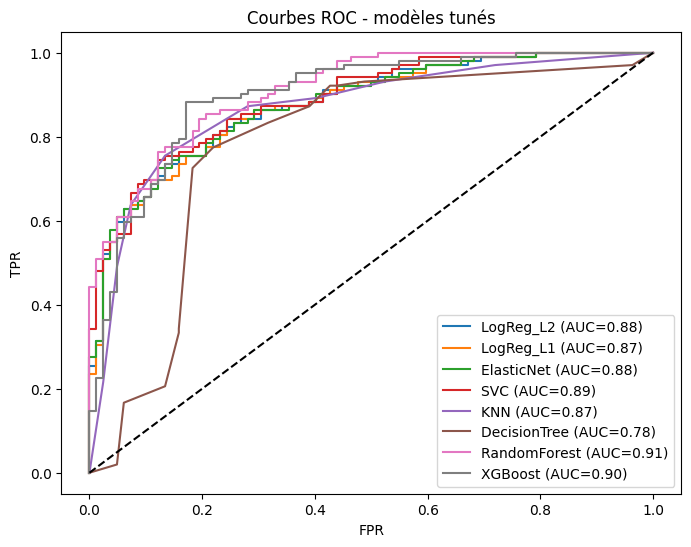

,Model,Best Parameters
0,LogReg_L2,"{'C': 0.1, 'class_weight': None, 'dual': False..."
1,LogReg_L1,"{'C': 1, 'class_weight': None, 'dual': False, ..."
2,ElasticNet,"{'C': 0.1, 'class_weight': None, 'dual': False..."
3,SVC,"{'C': 0.1, 'break_ties': False, 'cache_size': ..."
4,KNN,"{'algorithm': 'auto', 'leaf_size': 30, 'metric..."
5,DecisionTree,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit..."
6,RandomForest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
7,XGBoost,"{'objective': 'binary:logistic', 'base_score':..."


In [19]:
from sklearn.metrics import auc
param_grids = {

    "LogReg_L2": {
        "C": [0.01, 0.1, 1, 10]
    },

    "LogReg_L1": {
        "C": [0.01, 0.1, 1, 10]
    },

    "ElasticNet": {
        "C": [0.01, 0.1, 1],
        "l1_ratio": [0.3, 0.5, 0.7]
    },

    "SVC": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"]
    },

    "KNN": {
        "n_neighbors": [3, 5, 7, 9]
    },

    "DecisionTree": {
        "max_depth": [3, 5, 10, None]
    },

    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10]
    },

    "XGBoost": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5]
    }
}


best_models = {}
y_preds_tuned = {}
y_probas_tuned = {}

for name, model in models.items():
    
    print(f"\n🔍 Tuning {name}...")
    
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,                 # ✔ 5-fold
        scoring='roc_auc',    # ✔ ROC AUC
        n_jobs=-1             # ✔ parallélisation
    )
    
    grid.fit(X_train_sel, y_train)
    
    best_model = grid.best_estimator_
    best_models[name] = best_model
    
    # prédictions
    y_preds_tuned[name] = best_model.predict(X_test_sel)
    y_probas_tuned[name] = best_model.predict_proba(X_test_sel)[:,1]
    
    print("Best params:", grid.best_params_)
    plt.figure(figsize=(16,12))

for i, name in enumerate(best_models.keys()):
    
    cm = confusion_matrix(y_test, y_preds_tuned[name])
    
    plt.subplot(3,3,i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()
for name in best_models.keys():
    
    print(f"\n📌 {name}")
    print(classification_report(y_test, y_preds_tuned[name]))
plt.figure(figsize=(8,6))

for name in best_models.keys():
    
    fpr, tpr, _ = roc_curve(y_test, y_probas_tuned[name])
   
    roc_auc_val = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_val:.2f})")

# ligne aléatoire
plt.plot([0,1],[0,1],'k--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Courbes ROC - modèles tunés")
plt.legend()
plt.show()
best_params_table = []

for name, model in best_models.items():
    
    best_params_table.append([name, model.get_params()])

best_params_df = pd.DataFrame(best_params_table, columns=[
    "Model", "Best Parameters"
])

best_params_df

# *8/ BASELINE VS TUNED*

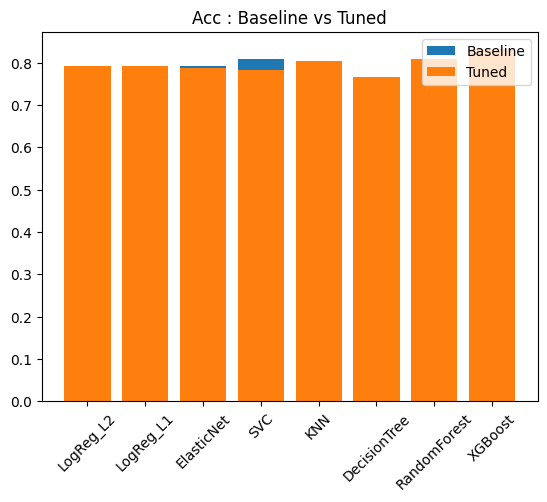

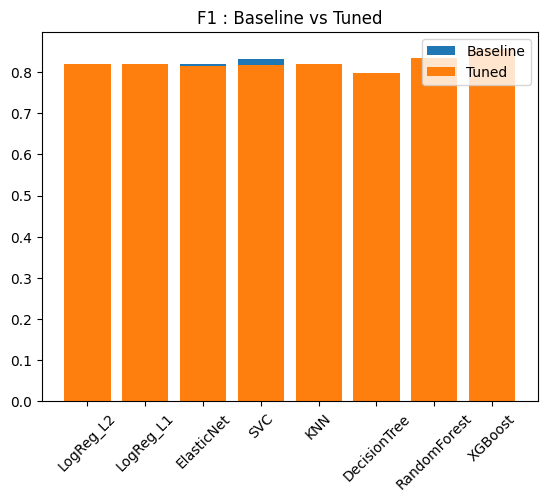

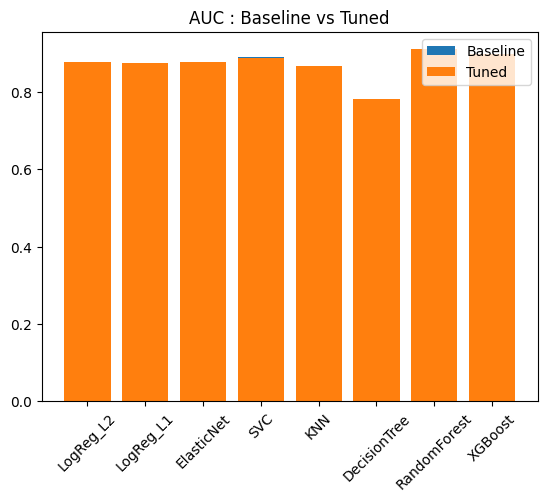

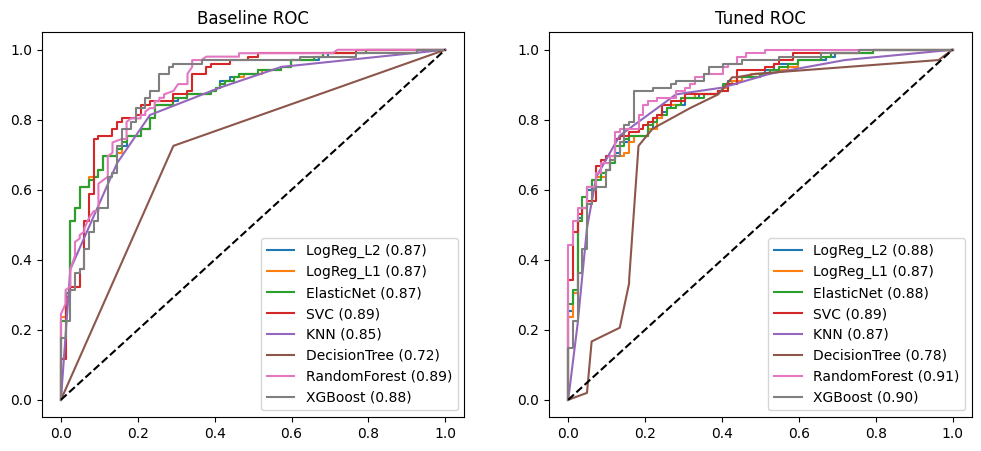

🏆 Meilleur modèle : RandomForest
Model        RandomForest
Acc_base         0.798913
Acc_tuned        0.809783
ΔAcc              0.01087
F1_base          0.821256
F1_tuned         0.834123
ΔF1              0.012867
AUC_base         0.892994
AUC_tuned        0.909254
ΔAUC              0.01626
Name: 6, dtype: object


In [20]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


comparison_final = []

for name in results_sel.keys():
    
    #  BASELINE
    y_pred_base = results_sel[name]["y_pred"]
    y_proba_base = results_sel[name]["y_proba"]
    
    acc_base = accuracy_score(y_test, y_pred_base)
    f1_base = f1_score(y_test, y_pred_base)
    auc_base = roc_auc_score(y_test, y_proba_base)
    
    #  TUNED
    y_pred_tuned = y_preds_tuned[name]
    y_proba_tuned = y_probas_tuned[name]
    
    acc_tuned = accuracy_score(y_test, y_pred_tuned)
    f1_tuned = f1_score(y_test, y_pred_tuned)
    auc_tuned = roc_auc_score(y_test, y_proba_tuned)
    
    #  DELTA
    comparison_final.append([
        name,
        acc_base, acc_tuned, acc_tuned - acc_base,
        f1_base, f1_tuned, f1_tuned - f1_base,
        auc_base, auc_tuned, auc_tuned - auc_base
    ])

comparison_final_df = pd.DataFrame(comparison_final, columns=[
    "Model",
    "Acc_base", "Acc_tuned", "ΔAcc",
    "F1_base", "F1_tuned", "ΔF1",
    "AUC_base", "AUC_tuned", "ΔAUC"
])

comparison_final_df.sort_values(by="AUC_tuned", ascending=False)


metrics = ["Acc", "F1", "AUC"]

for metric in metrics:
    
    plt.figure()
    
    base = comparison_final_df[f"{metric}_base"]
    tuned = comparison_final_df[f"{metric}_tuned"]
    
    x = range(len(comparison_final_df))
    
    plt.bar(x, base)
    plt.bar(x, tuned, bottom=base*0)  # côte à côte simple
    
    plt.xticks(x, comparison_final_df["Model"], rotation=45)
    plt.title(f"{metric} : Baseline vs Tuned")
    
    plt.legend(["Baseline", "Tuned"])
    plt.show()
    from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# 🔹 Baseline
for name in results_sel.keys():
    
    fpr, tpr, _ = roc_curve(y_test, results_sel[name]["y_proba"])
    auc_val = roc_auc_score(y_test, results_sel[name]["y_proba"])
    
    axes[0].plot(fpr, tpr, label=f"{name} ({auc_val:.2f})")

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title("Baseline ROC")
axes[0].legend()

# 🔹 Tuned
for name in y_probas_tuned.keys():
    
    fpr, tpr, _ = roc_curve(y_test, y_probas_tuned[name])
    auc_val = roc_auc_score(y_test, y_probas_tuned[name])
    
    axes[1].plot(fpr, tpr, label=f"{name} ({auc_val:.2f})")

axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title("Tuned ROC")
axes[1].legend()

plt.show()
best_model = comparison_final_df.sort_values(by="AUC_tuned", ascending=False).iloc[0]

print("🏆 Meilleur modèle :", best_model["Model"])
print(best_model)

## 9/Conclusion et Recommandations

### 🔹 Synthèse des résultats

Dans ce projet, plusieurs modèles de machine learning ont été développés et évalués afin de prédire la présence d’une maladie cardiaque.

Les principales étapes ont inclus :

* Le nettoyage et le prétraitement des données
* L’analyse exploratoire
* La modélisation avec 8 algorithmes
* La sélection de variables via Backward Elimination
* L’optimisation des hyperparamètres (fine-tuning)

Les résultats montrent que :

* Les modèles obtiennent des performances globalement élevées
* La réduction dimensionnelle n’a pas significativement amélioré les performances
* Le fine-tuning a permis des améliorations légères mais limitées

---

### 🔹 Meilleur modèle identifié

Le meilleur modèle a été sélectionné sur la base du score **ROC AUC**, qui mesure la capacité de discrimination du modèle.

👉 Le modèle retenu est : **Random Forest**

####  Justification :

* Score ROC AUC le plus élevé parmi les modèles testés
* Bon équilibre entre précision et rappel
* Stabilité des performances avant et après tuning
* Capacité à gérer les variables non pertinentes et les interactions complexes

---

### 🔹 Limites du projet

Malgré les résultats obtenus, certaines limites doivent être soulignées :

####  Taille du dataset

* Le nombre d’observations reste limité
* Risque de surapprentissage (overfitting)

####  Données multi-centres

* Les données peuvent provenir de différentes sources
* Hétérogénéité potentielle des mesures

####  Binarisation de la variable cible

* La transformation en classification binaire simplifie le problème
* Perte d’information sur la gravité de la maladie

---

### 🔹 Perspectives et améliorations

Plusieurs pistes peuvent être envisagées pour améliorer ce travail :

####  1. Déploiement

* Intégration du modèle dans une application web
* Aide à la décision médicale en temps réel

####  2. Collecte de données supplémentaires

* Augmenter la taille du dataset
* Améliorer la généralisation du modèle

####  3. Approches Deep Learning

* Tester des modèles plus avancés (réseaux de neurones)
* Capturer des relations complexes entre variables

---

###  Conclusion générale

Ce projet a permis de mettre en œuvre un pipeline complet de machine learning, allant du prétraitement à l’optimisation des modèles.

Les résultats obtenus montrent que le modèle **Random Forest** offre les meilleures performances globales, tout en étant robuste et stable.

Des améliorations futures sont possibles, notamment via l’augmentation des données et l’utilisation de techniques plus avancées.

---
